# Step 9: Feature Importance & Interpretability
### DI 501 Term Project | Eda Yilmaz

**Goal:**  
Understand *how* the tuned Random Forest uses `heat_stress_days` and `prec_gs` to predict detrended yield.

**Methods:**
1. **Impurity-based feature importance** (RF built-in) — overall and per cluster
2. **Permutation importance** — more reliable, measures actual predictive contribution
3. **Partial dependence plots** — how each feature relates to predicted yield, holding the other fixed

---

## 1. Load Data & Fit Tuned RF

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

plt.rcParams['figure.dpi'] = 120

SELECTED_FEATURES = ['heat_stress_days', 'prec_gs']
FEATURE_LABELS    = ['Heat Stress Days', 'Precip GS (mm)']
TARGET            = 'detrended_yield'
CLUSTERS          = [0, 1, 2]
CLUSTER_COLORS    = {0: '#e07b39', 1: '#3b82c4', 2: '#5aad5a'}
ML_EXCLUDE        = ['BR', 'US']

df = pd.read_csv('./master_global_ml_dataset.csv').dropna(
    subset=SELECTED_FEATURES + [TARGET]
)
df = df[~df['country'].isin(ML_EXCLUDE)].copy()

# ── Find best RF params via GridSearch (same grid as Step 7) ─────────────────
print('Running GridSearchCV to find best RF hyperparameters...')
scaler = StandardScaler()
X_all = scaler.fit_transform(df[SELECTED_FEATURES].values)
y_all = df[TARGET].values

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [50,100,200], 'max_depth': [3,5,8,None], 'min_samples_leaf': [5,10,20]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
rf_grid.fit(X_all, y_all)

RF_BEST_PARAMS = rf_grid.best_params_
print(f'Best RF params: {RF_BEST_PARAMS}')

# Fit RF on full training set (scaled) for interpretability
rf = RandomForestRegressor(random_state=42, **RF_BEST_PARAMS)
rf.fit(X_all, y_all)

print()
print(f'RF trained on full dataset ({df["country"].nunique()} countries, BR+US excluded).')
print(f'Training set: {len(df):,} observations')

Running GridSearchCV to find best RF hyperparameters...
Best RF params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 200}

RF trained on full dataset (36 countries, BR+US excluded).
Training set: 30,278 observations


---
## 2. Overall Feature Importance

OVERALL FEATURE IMPORTANCE

Feature                Impurity-based     Permutation (mean+/-std)
------------------------------------------------------------
Heat Stress Days       0.3536             0.0561 +/- 0.0016
Precip GS (mm)         0.6464             0.0896 +/- 0.0023


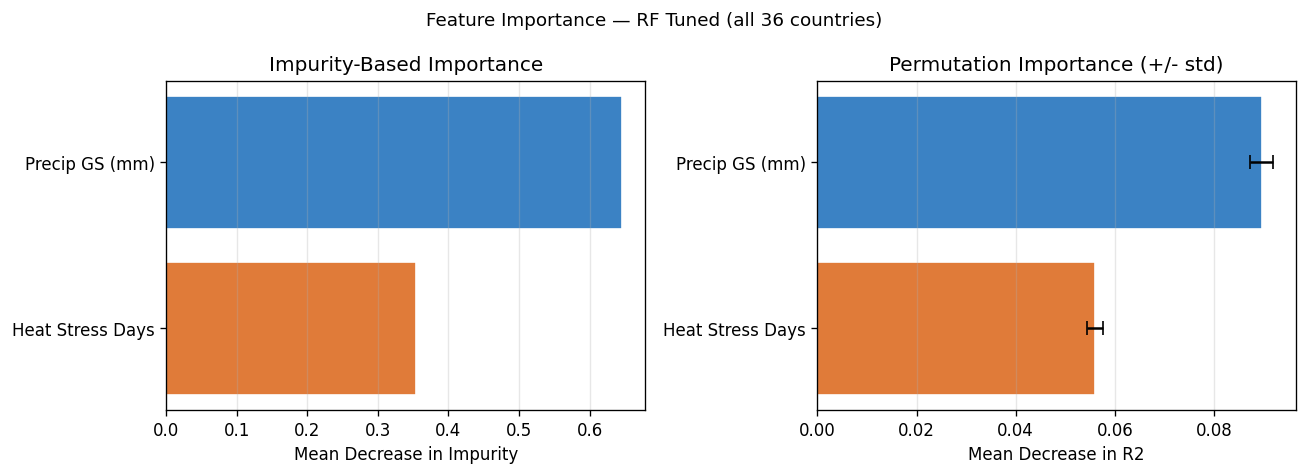

Saved: fig_feature_importance_global.png


In [7]:
# ── Impurity-based importance ────────────────────────────────────────────────
imp_impurity = rf.feature_importances_

# ── Permutation importance ───────────────────────────────────────────────────
perm = permutation_importance(rf, X_all, y_all, n_repeats=30, random_state=42, n_jobs=-1)
imp_perm_mean = perm.importances_mean
imp_perm_std  = perm.importances_std

print('OVERALL FEATURE IMPORTANCE')
print()
imp_header = f'{"Feature":<22} {"Impurity-based":<18} {"Permutation (mean+/-std)"}'
print(imp_header)
print('-' * 60)
for feat, imp_i, imp_p, std_p in zip(FEATURE_LABELS, imp_impurity, imp_perm_mean, imp_perm_std):
    print(f'{feat:<22} {imp_i:<18.4f} {imp_p:.4f} +/- {std_p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(FEATURE_LABELS, imp_impurity, color=['#e07b39','#3b82c4'], edgecolor='white')
axes[0].set_title('Impurity-Based Importance')
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(FEATURE_LABELS, imp_perm_mean, xerr=imp_perm_std,
             color=['#e07b39','#3b82c4'], edgecolor='white', capsize=4)
axes[1].set_title('Permutation Importance (+/- std)')
axes[1].set_xlabel('Mean Decrease in R2')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — RF Tuned (all 36 countries)', fontsize=11)
plt.tight_layout()
plt.savefig('./fig_feature_importance_global.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_feature_importance_global.png')

---
## 3. Per-Cluster Feature Importance

Fit a separate RF per cluster to see how feature importance shifts across climate groups.

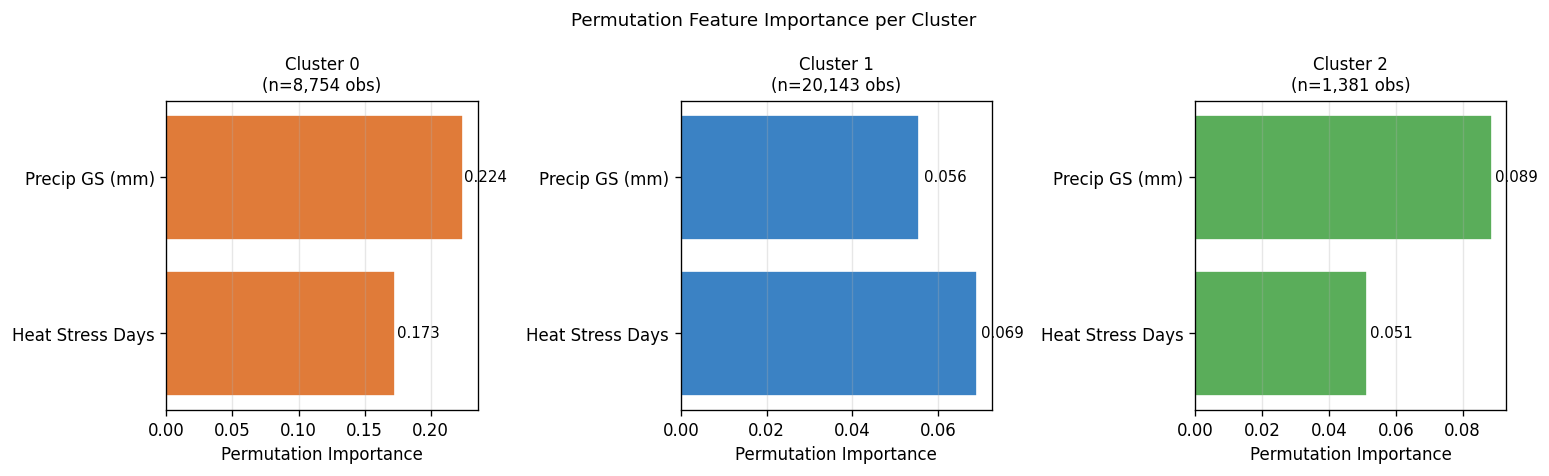

Saved: fig_feature_importance_per_cluster.png

Per-cluster importance summary:
  Cluster 0: dominant feature = Precip GS (mm) (0.224)
  Cluster 1: dominant feature = Heat Stress Days (0.069)
  Cluster 2: dominant feature = Precip GS (mm) (0.089)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

cluster_importances = {}
for ax, c in zip(axes, CLUSTERS):
    sub = df[df['cluster'] == c]
    if len(sub) < 50:
        ax.set_title(f'Cluster {c} (too few obs)')
        continue
    X_c = scaler.transform(sub[SELECTED_FEATURES].values)
    y_c = sub[TARGET].values
    rf_c = RandomForestRegressor(random_state=42, **RF_BEST_PARAMS)
    rf_c.fit(X_c, y_c)
    
    perm_c = permutation_importance(rf_c, X_c, y_c, n_repeats=20, random_state=42, n_jobs=-1)
    imp = perm_c.importances_mean
    cluster_importances[c] = imp
    
    bars = ax.barh(FEATURE_LABELS, imp, color=CLUSTER_COLORS[c], edgecolor='white')
    ax.set_title(f'Cluster {c}\n(n={len(sub):,} obs)', fontsize=10)
    ax.set_xlabel('Permutation Importance')
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, imp):
        ax.text(max(val + 0.001, 0.001), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Permutation Feature Importance per Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('./fig_feature_importance_per_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_feature_importance_per_cluster.png')
print()
print('Per-cluster importance summary:')
for c, imp in cluster_importances.items():
    dominant = FEATURE_LABELS[np.argmax(imp)]
    print(f'  Cluster {c}: dominant feature = {dominant} ({imp[np.argmax(imp)]:.3f})')

---
## 4. Partial Dependence Plots

How does predicted detrended yield change as each feature varies, holding the other constant?

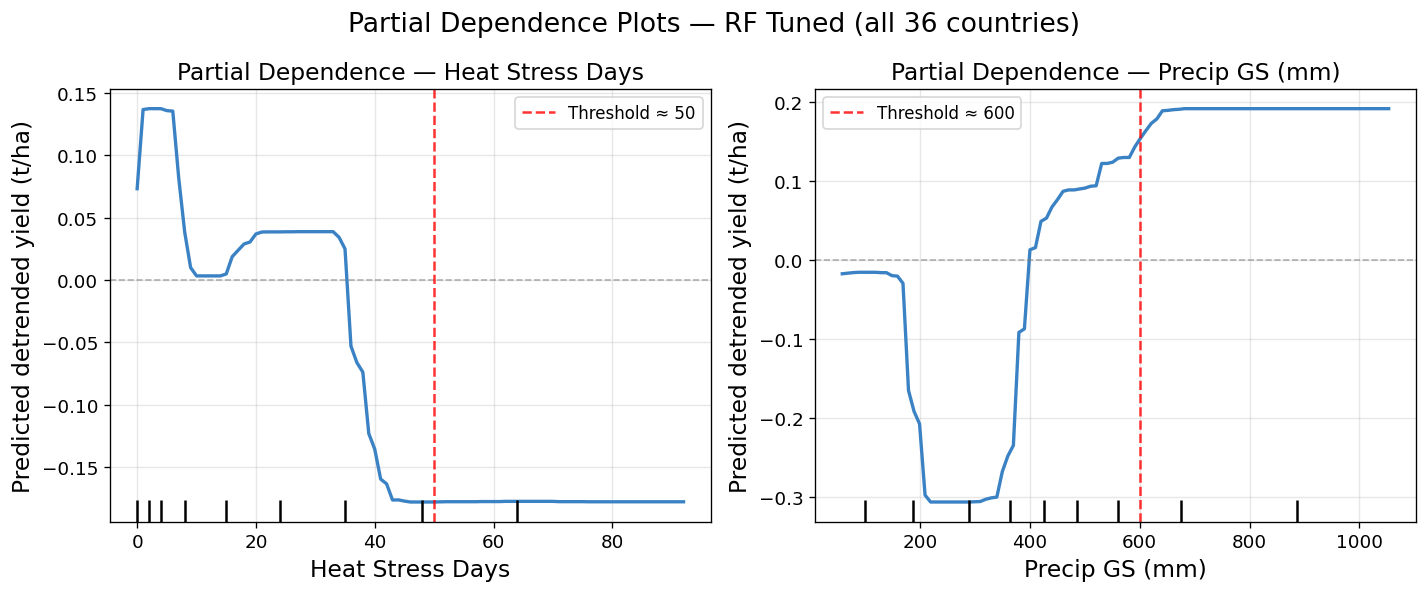

Saved: fig_partial_dependence.png


In [10]:
from sklearn.pipeline import Pipeline

# ── Build Pipeline (scaler + RF) so PDP x-axis shows original units ──────────
X_raw = df[SELECTED_FEATURES].values  # unscaled

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42, **RF_BEST_PARAMS))
])
pipe.fit(X_raw, y_all)

# ── Partial Dependence Plots in original units ────────────────────────────────
THRESHOLDS = [50, 600]   # ~50 heat stress days, ~600 mm precipitation

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feat_idx, feat_name, thresh in zip(axes, [0, 1], FEATURE_LABELS, THRESHOLDS):
    disp = PartialDependenceDisplay.from_estimator(
        pipe, X_raw, features=[feat_idx],
        feature_names=FEATURE_LABELS,
        ax=ax, line_kw={'color': '#3b82c4', 'linewidth': 2}
    )
    # Use disp.axes_ to ensure we draw on the correct axes object
    pdp_ax = disp.axes_[0][0]
    pdp_ax.set_title(f'Partial Dependence — {feat_name}', fontsize=14)
    pdp_ax.set_xlabel(feat_name, fontsize=14)
    pdp_ax.set_ylabel('Predicted detrended yield (t/ha)', fontsize=14)
    pdp_ax.tick_params(axis='both', labelsize=11)
    pdp_ax.grid(alpha=0.3)
    pdp_ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.6)
    pdp_ax.axvline(thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
                   label=f'Threshold ≈ {thresh}')
    pdp_ax.legend(fontsize=10)

plt.suptitle('Partial Dependence Plots — RF Tuned (all 36 countries)', fontsize=16)
plt.tight_layout()
plt.savefig('./fig_partial_dependence.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_partial_dependence.png')

---
## 5. Summary

In [6]:
print('INTERPRETABILITY SUMMARY')
print()
print('1. OVERALL IMPORTANCE')
for feat, imp_p in zip(FEATURE_LABELS, imp_perm_mean):
    print(f'   {feat}: permutation importance = {imp_p:.4f}')
print()
print('2. PER-CLUSTER DOMINANT FEATURE')
for c, imp in cluster_importances.items():
    dominant = FEATURE_LABELS[np.argmax(imp)]
    other    = FEATURE_LABELS[1 - np.argmax(imp)]
    print(f'   Cluster {c}: {dominant} dominates over {other}')
print()
print('3. PARTIAL DEPENDENCE INTERPRETATION')
print('   heat_stress_days: expected negative relationship (more heat stress = lower yield)')
print('   prec_gs:          expected positive relationship (more rain = higher yield)')
print('   Deviations from these patterns (if any) are discussed in the paper.')
print()
print('Next steps: Steps 10-11 — Policy Implications & Conclusion')

INTERPRETABILITY SUMMARY

1. OVERALL IMPORTANCE
   Heat Stress Days: permutation importance = 0.0561
   Precip GS (mm): permutation importance = 0.0896

2. PER-CLUSTER DOMINANT FEATURE
   Cluster 0: Precip GS (mm) dominates over Heat Stress Days
   Cluster 1: Heat Stress Days dominates over Precip GS (mm)
   Cluster 2: Precip GS (mm) dominates over Heat Stress Days

3. PARTIAL DEPENDENCE INTERPRETATION
   heat_stress_days: expected negative relationship (more heat stress = lower yield)
   prec_gs:          expected positive relationship (more rain = higher yield)
   Deviations from these patterns (if any) are discussed in the paper.

Next steps: Steps 10-11 — Policy Implications & Conclusion
